# Preparation for interpolation

In [8]:
import sys
sys.path.append('../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

# Preparation interpolation

search F range 

In [9]:
sigma_rsl = 5000
sigmas = np.linspace(0.01, 59.4, sigma_rsl)
# sigmas = np.linspace(0.01, 8, sigma_rsl)
print([np.min(sigmas), np.max(sigmas)])

C0s = np.zeros_like(sigmas)
As = np.zeros_like(sigmas)
Vars_sqrt = np.zeros_like(sigmas)

pbar = tqdm(sigmas)
for i, sigma in enumerate(pbar):
    pbar.set_description(f"Processing sigma={sigma:.4f}")
    
    C0 = C0_sigma(sigma,
                 #  condition='median'
                  )
    C0s[i] = C0
    
    if C0==None:
        print(f"Warning: C0 is None for sigma={sigma:.4f}")
        A=None
        Vars_sqrt[i] = None
    else:
        A = find_A_sigma(C_0=C0, sigma=sigma)
        As[i] = A
        Vars_sqrt[i] = np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

[0.01, 59.4]


Processing sigma=16.0247:  27%|██▋       | 1341/5000 [08:00<39:53,  1.53it/s]  

Processing sigma=59.4000: 100%|██████████| 5000/5000 [40:46<00:00,  2.04it/s]  


In [10]:
mask = ~pd.isnull(C0s) & ~pd.isnull(As) & ~pd.isnull(Vars_sqrt)
C0s = C0s[mask]
As = As[mask]
Vars_sqrt = Vars_sqrt[mask]
sigmas = sigmas[mask]
print(len(sigmas), len(C0s), len(As), len(Vars_sqrt))

4999 4999 4999 4999


In [11]:
# sigma_rsl=5000
# # sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
# sigmas=np.linspace(0.1, 59.0, sigma_rsl)
# print([np.min(sigmas),np.max(sigmas)])
# C0s=np.zeros_like(sigmas)
# As=np.zeros_like(sigmas)
# Vars_sqrt=np.zeros_like(sigmas)
# for i, sigma in enumerate(sigmas):
#     C0=C0_sigma(sigma)
#     C0s[i]=C0
#     A=find_A_sigma(C_0=C0, sigma=sigma)
#     As[i]=A
#     Vars_sqrt[i]=np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

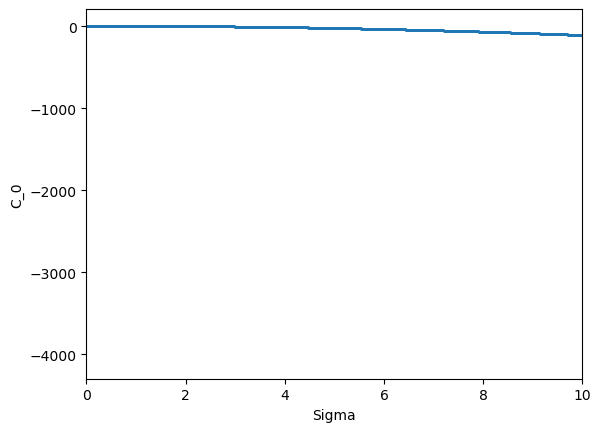

In [12]:
plt.scatter(sigmas, C0s,  s=1)

plt.ylabel('C_0')
plt.xlabel('Sigma')
plt.xlim(0,10)

plt.show()

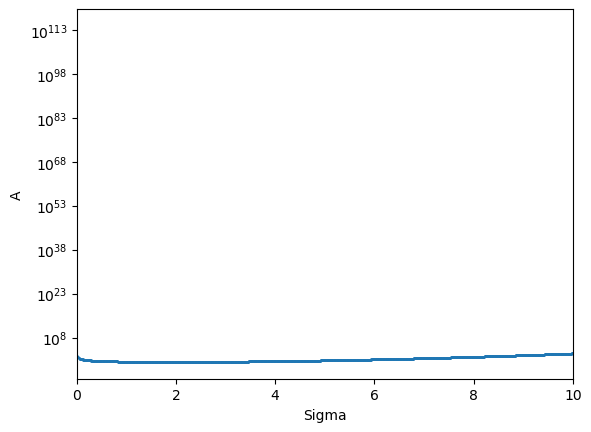

In [13]:
plt.scatter(sigmas, As,  s=1)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
plt.xlim(0,10)

plt.show()

(11.6, 11.8)

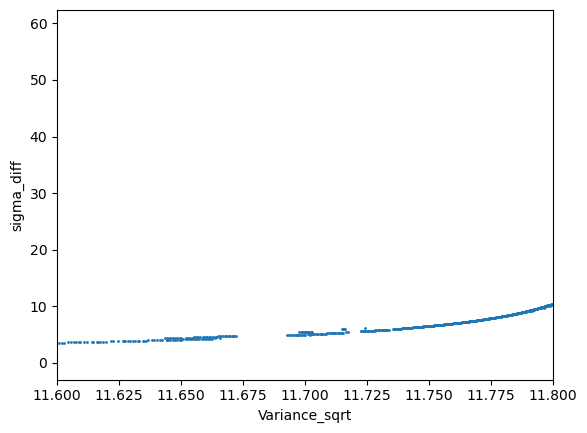

In [14]:
plt.scatter(Vars_sqrt, sigmas,s=1)
plt.ylabel('sigma_diff')
plt.xlabel('Variance_sqrt')
plt.xlim(11.6,11.8)
# plt.xscale('log')
# plt.yscale('log')

In [15]:
def f_var_sigma(sigma_rsl):
    sigmas = np.linspace(0.01, 59.4, sigma_rsl)
    # sigmas = np.linspace(0.01, 8, sigma_rsl)

    C0s = np.zeros_like(sigmas)
    As = np.zeros_like(sigmas)
    Vars_sqrt = np.zeros_like(sigmas)

    pbar = tqdm(sigmas)
    for i, sigma in enumerate(pbar):
        pbar.set_description(f"Processing sigma={sigma:.4f}")
    
        C0 = C0_sigma(sigma,
                 #  condition='median'
                  )
        C0s[i] = C0
        A = find_A_sigma(C_0=C0, sigma=sigma)
        As[i] = A
        Vars_sqrt[i] = np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))
        
    return sigmas, Vars_sqrt, C0s, As

In [16]:
sigmas100, Vars_sqrt100, C0s100, As100 = f_var_sigma(100)
sigmas200, Vars_sqrt200, C0s200, As200 = f_var_sigma(200)
sigmas500, Vars_sqrt500, C0s500, As500 = f_var_sigma(500)
sigmas1000, Vars_sqrt1000, C0s1000, As1000 = f_var_sigma(1000)
sigmas2000, Vars_sqrt2000, C0s2000, As2000 = f_var_sigma(2000)

Processing sigma=59.4000: 100%|██████████| 2000/2000 [15:34<00:00,  2.14it/s]


Text(0.5, 0, 'Sigma')

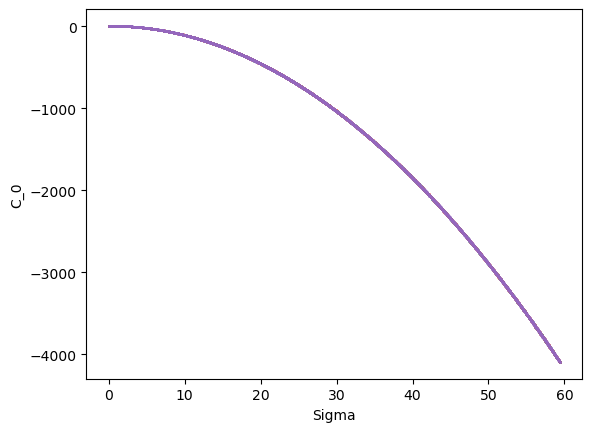

In [17]:
plt.scatter(sigmas100, C0s100, s=1, label='sigma_rsl=100')
plt.scatter(sigmas200, C0s200, s=1, label='sigma_rsl=200')
plt.scatter(sigmas500, C0s500, s=1, label='sigma_rsl=500')
plt.scatter(sigmas1000, C0s1000, s=1, label='sigma_rsl=1000')
plt.scatter(sigmas2000, C0s2000, s=1, label='sigma_rsl=2000')
plt.ylabel('C_0')
plt.xlabel('Sigma')

Text(0.5, 0, 'Sigma')

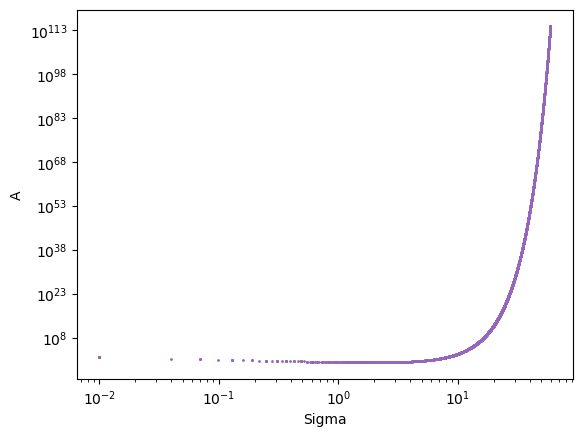

In [18]:
plt.scatter(sigmas100, As100, s=1, label='sigma_rsl=100')
plt.scatter(sigmas200, As200, s=1, label='sigma_rsl=200')
plt.scatter(sigmas500, As500, s=1, label='sigma_rsl=500')
plt.scatter(sigmas1000, As1000, s=1, label='sigma_rsl=1000')
plt.scatter(sigmas2000, As2000, s=1, label='sigma_rsl=2000')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('A')
plt.xlabel('Sigma')

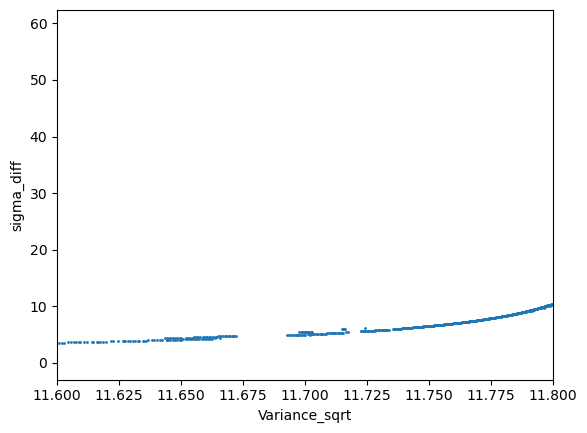

In [28]:
# plt.scatter(Vars_sqrt100, sigmas100, s=1, label='sigma_rsl=100')
# plt.scatter(Vars_sqrt200, sigmas200, s=1, label='sigma_rsl=200')
# plt.scatter(Vars_sqrt500, sigmas500, s=1, label='sigma_rsl=500')
# plt.scatter(Vars_sqrt1000, sigmas1000, s=1, label='sigma_rsl=1000')
# plt.scatter(Vars_sqrt2000, sigmas2000, s=1, label='sigma_rsl=2000')
plt.scatter(Vars_sqrt, sigmas, s=1, label='sigma_rsl=5000')
plt.xlim(11.6,11.8)
plt.ylabel('sigma_diff')
plt.xlabel('Variance_sqrt')
plt.show()

In [29]:
var_sigma100 = interpolate.interp1d(Vars_sqrt100, sigmas100, kind=1, fill_value='extrapolate')
var_sigma200 = interpolate.interp1d(Vars_sqrt200, sigmas200, kind=1, fill_value='extrapolate')
var_sigma500 = interpolate.interp1d(Vars_sqrt500, sigmas500, kind=1, fill_value='extrapolate')
var_sigma1000 = interpolate.interp1d(Vars_sqrt1000, sigmas1000, kind=1, fill_value='extrapolate')
var_sigma2000 = interpolate.interp1d(Vars_sqrt2000, sigmas2000, kind=1, fill_value='extrapolate')
var_sigma5000 = interpolate.interp1d(Vars_sqrt, sigmas, kind=1, fill_value='extrapolate')

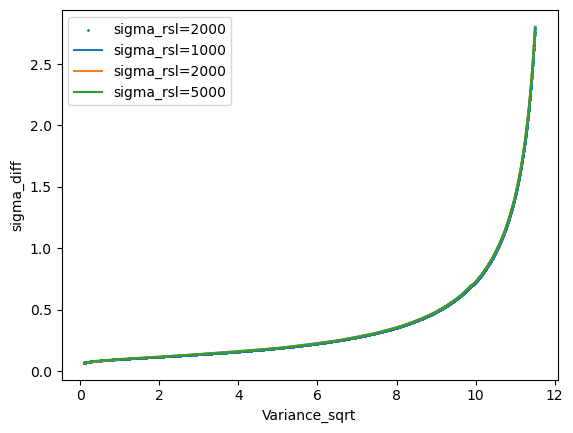

In [35]:
var_s=np.linspace(0.1,11.5,5000)
v_sigma100=var_sigma100(var_s)
v_sigma200=var_sigma200(var_s)
v_sigma500=var_sigma500(var_s)
v_sigma1000=var_sigma1000(var_s)
v_sigma2000=var_sigma2000(var_s)
v_sigma5000=var_sigma5000(var_s)
plt.scatter(var_s, v_sigma5000, s=1, label='sigma_rsl=2000')
# plt.plot(var_s, v_sigma100, label='sigma_rsl=100')

# plt.plot(var_s, v_sigma500, label='sigma_rsl=500')
plt.plot(var_s, v_sigma1000, label='sigma_rsl=1000')
plt.plot(var_s, v_sigma2000, label='sigma_rsl=2000')
plt.plot(var_s, v_sigma5000, label='sigma_rsl=5000')
plt.xlabel('Variance_sqrt')
plt.ylabel('sigma_diff')
# plt.xscale('log')
# plt.yscale('log')
# plt.xlim(11.6,11.8)
plt.legend()

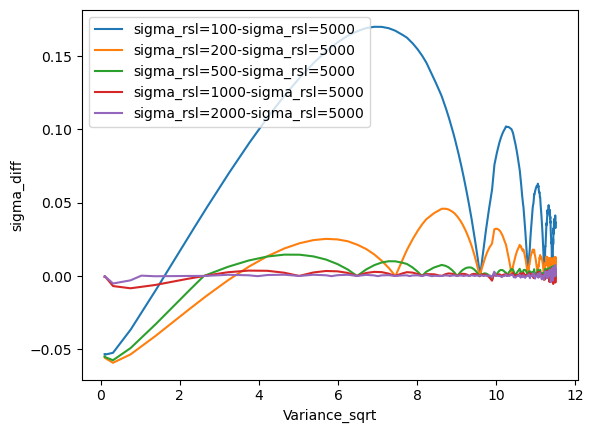

In [37]:
plt.plot(var_s, v_sigma100-v_sigma5000, label='sigma_rsl=100-sigma_rsl=5000')
plt.plot(var_s, v_sigma200-v_sigma5000, label='sigma_rsl=200-sigma_rsl=5000')
plt.plot(var_s, v_sigma500-v_sigma5000, label='sigma_rsl=500-sigma_rsl=5000')
plt.plot(var_s, v_sigma1000-v_sigma5000, label='sigma_rsl=1000-sigma_rsl=5000')
plt.plot(var_s, v_sigma2000-v_sigma5000, label='sigma_rsl=2000-sigma_rsl=5000')
plt.xlabel('Variance_sqrt')
plt.ylabel('sigma_diff')
plt.legend()

In [33]:
t_var=11.678
print(var_sigma100(t_var))
print(var_sigma200(t_var))
print(var_sigma500(t_var))
print(var_sigma1000(t_var))
print(var_sigma2000(t_var))
print(var_sigma5000(t_var))

4.966929841321889
4.845309883078979
4.80652718734052
4.841574108024598
4.810182677274025
4.808038080565064


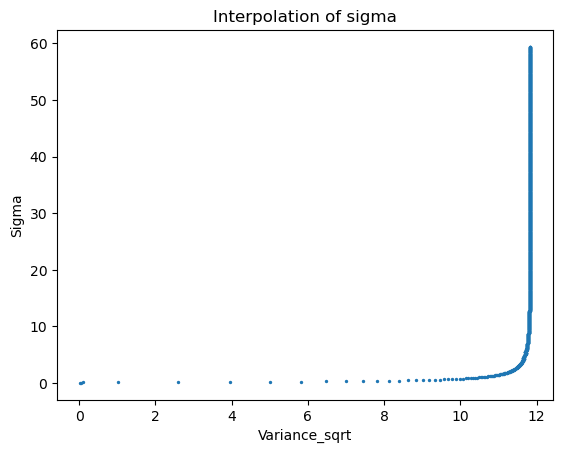

In [ ]:
plt.scatter(Vars_sqrt, sigmas, s=2)
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Variance_sqrt')
plt.ylabel('Sigma')
# plt.xlim(8.6,9)
plt.title('Interpolation of sigma')
plt.show()

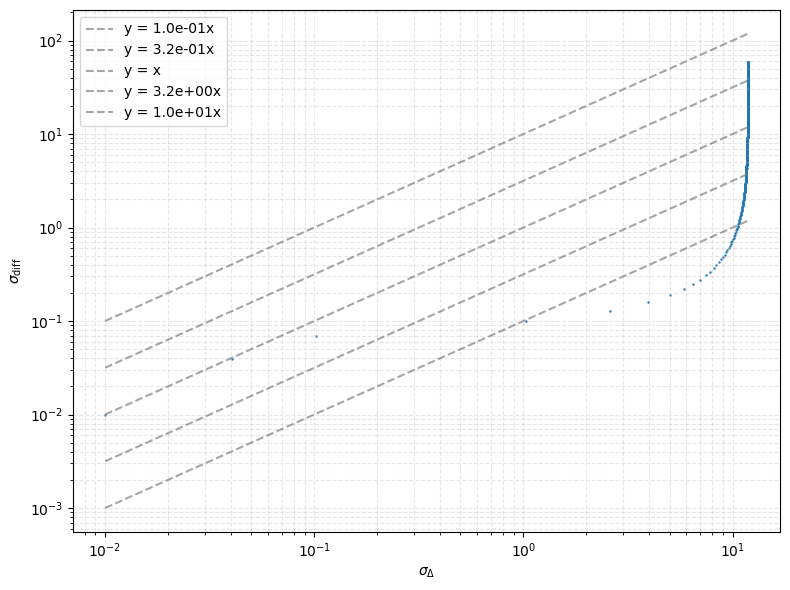

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(Vars_sqrt, sigmas,s=0.5)
plt.ylabel(r'$\sigma_{\rm diff}$')
plt.xlabel(r'$\sigma_\Delta$')
plt.xscale('log')
plt.yscale('log')

x_min = min(Vars_sqrt)
x_max = max(Vars_sqrt)
x_range = np.logspace(np.log10(x_min), np.log10(x_max), 100)

constants = [-1, -0.5, 0, 0.5, 1]
for c in constants:
    y_ref = x_range * (10**c)  # y = x * 10^c
    plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=f'y = {10**c:.1e}x' if c != 0 else 'y = x')

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()

In [ ]:
# interpolation example

# C0_sigma = interpolate.interp1d(sigmas, C0s, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# A_sigma = interpolate.interp1d(sigmas, As, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# sigma_var = interpolate.interp1d(Vars_sqrt, sigmas, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

In [ ]:
np.save('./interpolation/sigmas.npy', sigmas)
np.save('./interpolation/As.npy', As)
np.save('./interpolation/C0s.npy', C0s)
np.save('./interpolation/Vars_sqrt.npy', Vars_sqrt)